# 🔥 Spotify EDA — Multivariate Analysis

This notebook explores advanced relationships between multiple Spotify audio features, genres, and popularity patterns.

In [1]:
# =========================================
# IMPORT REQUIRED LIBRARIES
# =========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
# =========================================
# LOAD CLEANED DATASET
# =========================================

df = pd.read_csv("../data/cleaned/spotify_cleaned.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [3]:
# Quick dataset preview

df.head()


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# 🎯 Popularity Categories

In [4]:
# =========================================
# CREATE POPULARITY CATEGORIES
# =========================================

df['popularity_category'] = pd.cut(
    df['popularity'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)

# Preview counts
df['popularity_category'].value_counts()

popularity_category
Low       51306
Medium    41828
High       4846
Name: count, dtype: int64

# 🎵 Danceability Across Popularity Categories

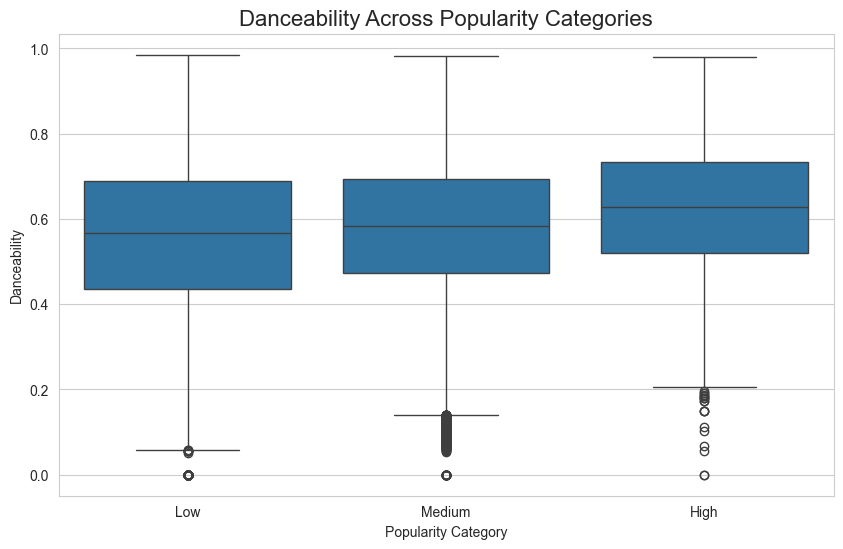

In [5]:
# =========================================
# DANCEABILITY VS POPULARITY CATEGORY
# =========================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='popularity_category',
    y='danceability'
)

plt.title("Danceability Across Popularity Categories", fontsize=16)
plt.xlabel("Popularity Category")
plt.ylabel("Danceability")
# DANCEABILITY ACROSS POPULARITY CATEGORIES
plt.savefig(
    "../visuals/charts/danceability_popularity_category.png",
    bbox_inches='tight'
)
plt.show()

### Observations

- High-popularity tracks exhibit slightly higher median danceability levels compared to low- and medium-popularity songs.
- The distribution suggests that more danceable tracks may have a greater likelihood of achieving higher popularity.
- All popularity categories display relatively broad danceability ranges, indicating substantial variation across tracks.
- Lower danceability outliers are more visible within medium- and high-popularity categories.
- Overall, danceability appears to contribute positively to track engagement, although it is not the sole factor influencing popularity.

# ⚡ Energy Across Popularity Categories

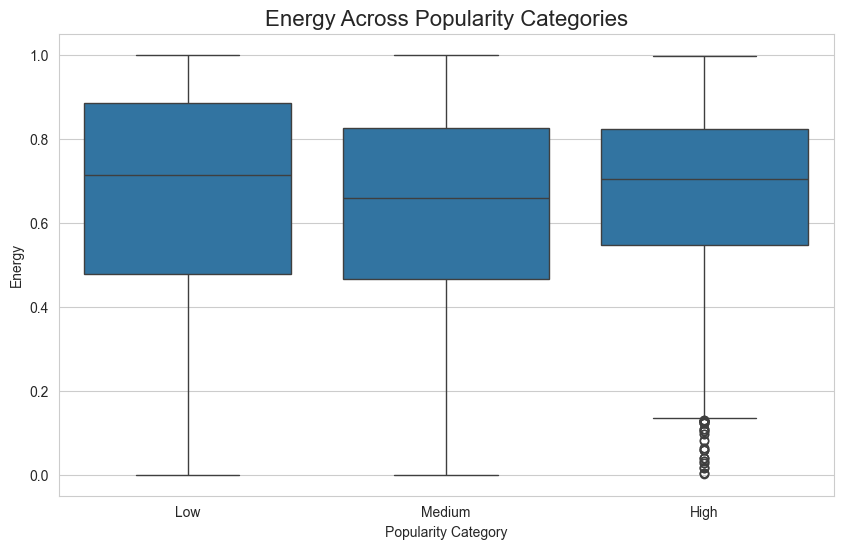

In [6]:
# =========================================
# ENERGY VS POPULARITY CATEGORY
# =========================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='popularity_category',
    y='energy'
)

plt.title("Energy Across Popularity Categories", fontsize=16)
plt.xlabel("Popularity Category")
plt.ylabel("Energy")
# ENERGY ACROSS POPULARITY CATEGORIES
plt.savefig(
    "../visuals/charts/energy_popularity_category.png",
    bbox_inches='tight'
)

plt.show()

### Observations

- High-popularity tracks tend to exhibit moderately high energy levels, with median energy values slightly higher than medium-popularity songs.
- Energy distributions remain relatively broad across all popularity categories, indicating diverse musical intensity levels within Spotify tracks.
- High-popularity songs appear more concentrated within moderate-to-high energy ranges.
- A few low-energy outliers are visible within the high-popularity category, suggesting that calmer tracks can still achieve strong listener engagement.
- Overall, higher energy levels appear somewhat associated with increased popularity, although the relationship is not extremely strong.

# 😊 Valence Across Popularity Categories

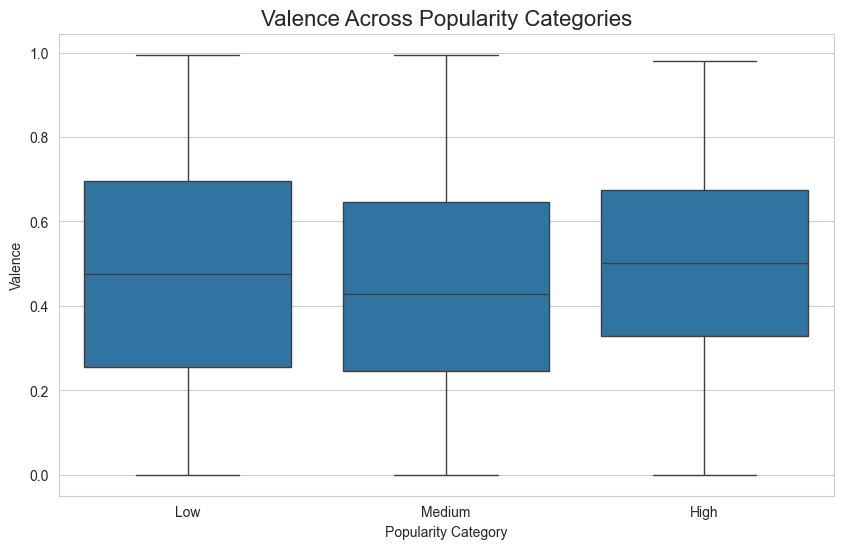

In [7]:
# =========================================
# VALENCE VS POPULARITY CATEGORY
# =========================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='popularity_category',
    y='valence'
)

plt.title("Valence Across Popularity Categories", fontsize=16)
plt.xlabel("Popularity Category")
plt.ylabel("Valence")
# VALENCE ACROSS POPULARITY CATEGORIES
plt.savefig(
    "../visuals/charts/valence_popularity_category.png",
    bbox_inches='tight'
)
plt.show()

### Observations

- High-popularity tracks display slightly higher median valence levels compared to low- and medium-popularity songs.
- Valence distributions remain relatively balanced across all popularity categories, indicating a wide range of emotional tones within Spotify tracks.
- Both positive and negative emotional tracks are capable of achieving strong popularity levels.
- The spread of valence values is fairly consistent across categories, suggesting similar emotional variability throughout the dataset.
- Overall, emotionally positive tracks may have a slight advantage in popularity, although valence alone does not strongly determine listener engagement.

# 🎼 Genre-wise Energy Analysis

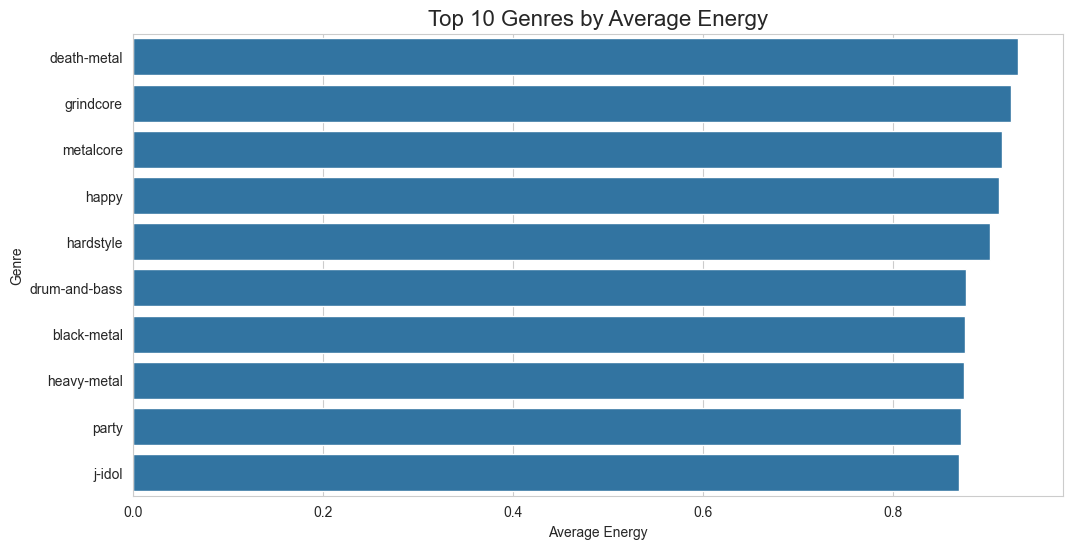

In [8]:
# =========================================
# TOP 10 GENRES BY AVERAGE ENERGY
# =========================================

# Calculate average energy by genre
genre_energy = (
    df.groupby('track_genre')['energy']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Create figure
plt.figure(figsize=(12, 6))

# Create barplot
sns.barplot(
    x=genre_energy.values,
    y=genre_energy.index
)

plt.title("Top 10 Genres by Average Energy", fontsize=16)
plt.xlabel("Average Energy")
plt.ylabel("Genre")
# TOP 10 GENRES BY AVERAGE ENERGY
plt.savefig(
    "../visuals/charts/top_genres_by_energy.png",
    bbox_inches='tight'
)
plt.show()

### Observations

- Metal and electronic-oriented genres such as death-metal, grindcore, metalcore, and hardstyle exhibit the highest average energy levels.
- High-energy genres are strongly associated with intense, fast-paced, and aggressive musical characteristics.
- Genres such as drum-and-bass and party music also demonstrate elevated energy levels, reflecting their energetic listening styles.
- The differences in average energy across the top genres are relatively moderate, with most high-energy genres clustered near very high energy values.
- Overall, the analysis suggests that Spotify’s most energetic genres are dominated by heavy metal and electronic music categories.

# 🎵 Genre-wise Danceability Analysis

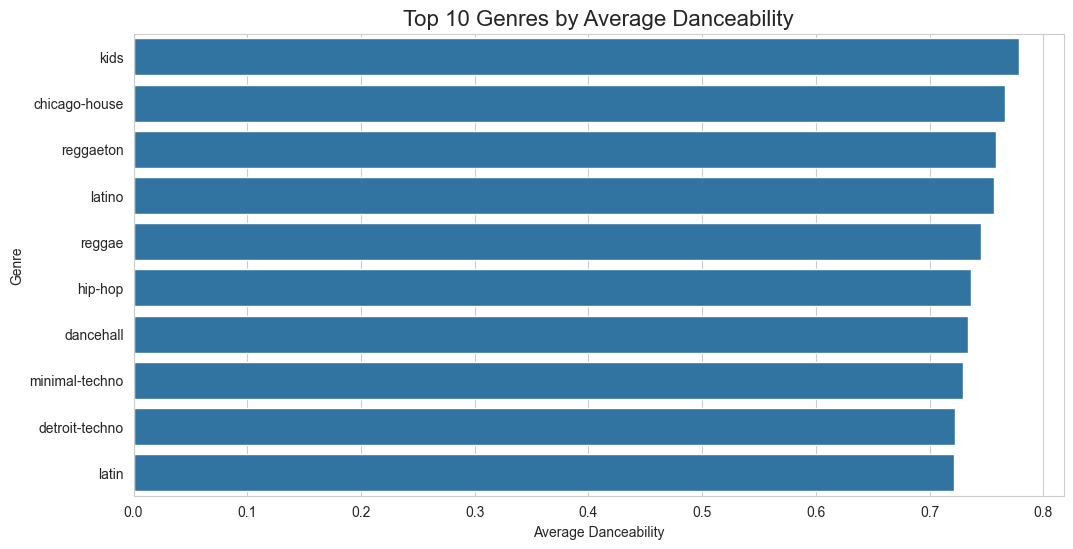

In [9]:
# =========================================
# TOP 10 GENRES BY AVERAGE DANCEABILITY
# =========================================

# Calculate average danceability by genre
genre_danceability = (
    df.groupby('track_genre')['danceability']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Create figure
plt.figure(figsize=(12, 6))

# Create barplot
sns.barplot(
    x=genre_danceability.values,
    y=genre_danceability.index
)

plt.title("Top 10 Genres by Average Danceability", fontsize=16)
plt.xlabel("Average Danceability")
plt.ylabel("Genre")
# TOP 10 GENRES BY AVERAGE DANCEABILITY
plt.savefig(
    "../visuals/charts/top_genres_by_danceability.png",
    bbox_inches='tight'
)
plt.show()

### Observations

- Genres such as kids, chicago-house, reggaeton, and latino exhibit the highest average danceability levels.
- Dance-focused genres including hip-hop, dancehall, and techno-related categories also demonstrate consistently high danceability scores.
- The average danceability values across the top genres are relatively close, indicating strong rhythmic characteristics among these music styles.
- Electronic, Latin, and rhythm-driven genres dominate the highly danceable category within the dataset.
- Overall, genres associated with strong beats and rhythmic patterns tend to achieve the highest danceability levels on Spotify.

# 🔥 Pairplot Analysis

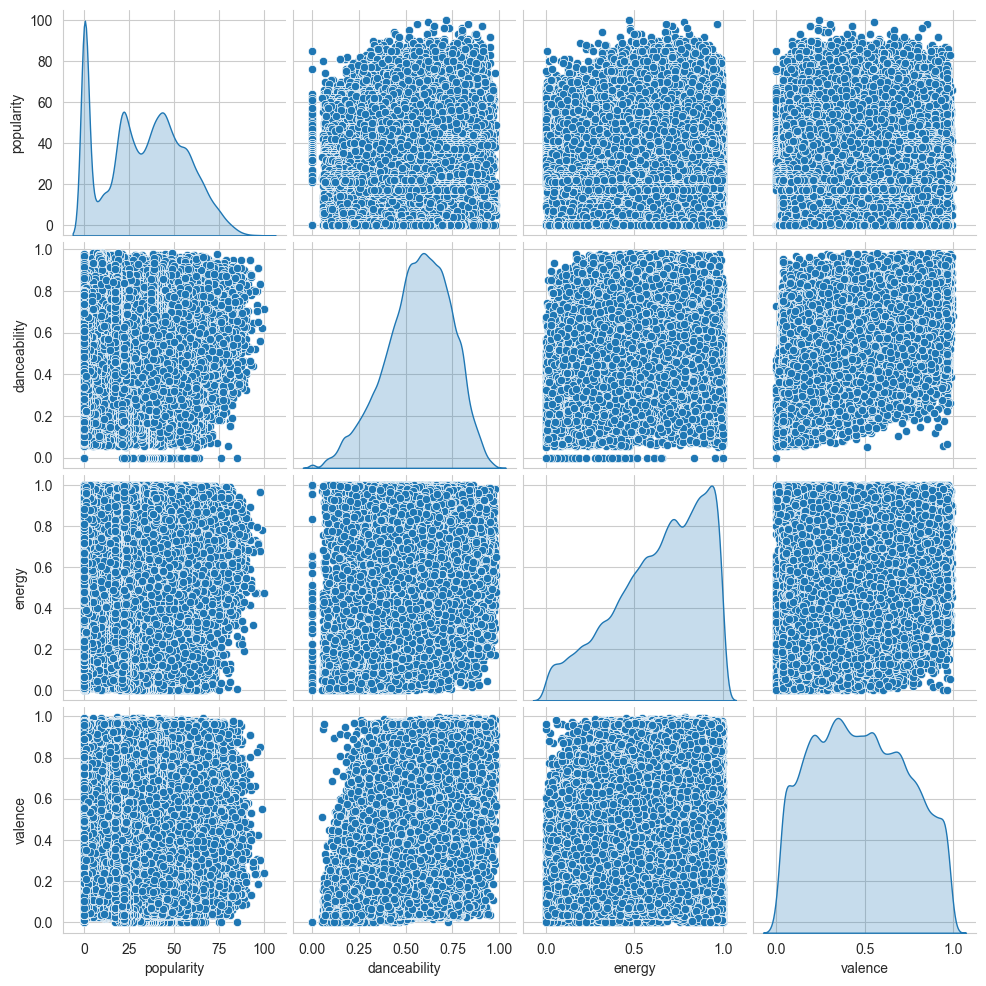

In [10]:
# =========================================
# PAIRPLOT OF KEY FEATURES
# =========================================

selected_features = [
    'popularity',
    'danceability',
    'energy',
    'valence'
]

sns.pairplot(
    df[selected_features],
    diag_kind='kde'
)
# PAIRPLOT OF KEY FEATURES
plt.savefig(
    "../visuals/charts/pairplot_key_features.png",
    bbox_inches='tight'
)
plt.show()

### Observations

- The pairplot reveals generally weak direct linear relationships between popularity and individual audio features such as danceability, energy, and valence.
- Danceability and valence display a mild positive relationship, suggesting that more danceable tracks often exhibit more positive emotional characteristics.
- Energy demonstrates broad variability across nearly all feature combinations, indicating substantial diversity in musical intensity levels.
- The diagonal KDE plots confirm earlier univariate findings, including moderate-to-high danceability and energy concentrations.
- Overall, the visualizations suggest that Spotify track popularity is influenced by multiple interacting factors rather than a single dominant audio characteristic.

# 📌 Multivariate Analysis Summary

### Key Findings

- High-popularity tracks generally exhibit slightly higher danceability and energy levels.
- Emotional positivity (valence) shows only a mild relationship with popularity.
- Genre-based analysis reveals that electronic, Latin, and metal-oriented genres dominate danceability and energy rankings.
- Correlation and pairplot analysis indicate that Spotify track popularity is influenced by multiple interacting musical characteristics.
- Strong relationships exist between features such as energy, loudness, and danceability, while popularity itself demonstrates weaker direct correlations.

### Conclusion

The multivariate analysis highlights the complexity of listener engagement patterns on Spotify.

Rather than relying on a single audio characteristic, successful tracks appear to combine multiple factors such as energy, rhythm, emotional tone, and genre-specific appeal to achieve higher popularity levels.